# AuraFitness Motivation Message Engine Testing

This notebook tests the rule-based motivation message generator.

Important:

- No LLM API is used.
- No ML training is used.
- Manual cases are controlled function tests only.
- No fake training dataset is used.
- Later, the React app will call this engine using real user actions and habit logs.

Message categories:

- completed workouts
- missed workouts
- new PRs
- streak progress
- fasting progress
- water progress
- calorie progress
- rest day discipline

In [1]:
from pathlib import Path
import sys
from dataclasses import asdict

import pandas as pd
import matplotlib.pyplot as plt

AI_ROOT = Path.cwd()

if AI_ROOT.name == "notebooks":
    AI_ROOT = AI_ROOT.parent

if str(AI_ROOT) not in sys.path:
    sys.path.append(str(AI_ROOT))

from utils.motivation_engine import MotivationRequest, generate_motivation_message

REPORTS_DIR = AI_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("AI root:", AI_ROOT)

AI root: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai


## Controlled message test cases

These cases test the motivation engine behavior.

They are not training data.

In [2]:
test_cases = [
    (
        "Workout completed weekly progress",
        MotivationRequest(
            event_type="workout_completed",
            user_name="Upamada",
            workout_name="Push Day",
            completed_workouts_this_week=3,
            weekly_workout_goal=5,
        ),
    ),
    (
        "Missed workout supportive",
        MotivationRequest(
            event_type="missed_workout",
            user_name="Upamada",
            workout_name="Leg Day",
            pain_reported=False,
        ),
    ),
    (
        "New PR",
        MotivationRequest(
            event_type="new_pr",
            user_name="Upamada",
            exercise_name="Bench Press",
            pr_value=60,
            pr_unit="kg",
        ),
    ),
    (
        "Workout streak progress",
        MotivationRequest(
            event_type="streak_progress",
            user_name="Upamada",
            streak_type="workout",
            current_streak=4,
            best_streak=4,
        ),
    ),
    (
        "Fasting progress",
        MotivationRequest(
            event_type="fasting_progress",
            user_name="Upamada",
            fasting_hours=14,
            fasting_goal_hours=16,
        ),
    ),
    (
        "Water goal reached",
        MotivationRequest(
            event_type="water_progress",
            user_name="Upamada",
            water_liters=3,
            water_goal_liters=3,
        ),
    ),
    (
        "Calories above target",
        MotivationRequest(
            event_type="calorie_progress",
            user_name="Upamada",
            calories=2400,
            calorie_goal=2200,
        ),
    ),
    (
        "Rest day followed",
        MotivationRequest(
            event_type="rest_day_followed",
            user_name="Upamada",
        ),
    ),
    (
        "Invalid water input",
        MotivationRequest(
            event_type="water_progress",
            water_liters=-1,
            water_goal_liters=3,
        ),
    ),
]

## Generate motivation messages

This cell runs the message generator and stores the outputs.

In [3]:
rows = []

for title, request in test_cases:
    message = generate_motivation_message(request)

    rows.append({
        "test_case": title,
        **asdict(message),
    })

results_df = pd.DataFrame(rows)
display(results_df)

,test_case,event_type,title,message,tone,confidence,reason_codes
0,Workout completed weekly progress,workout_completed,Workout completed,"Upamada, you completed Push Day. You are 3/5 w...",positive,0.86,"[workout_completed, weekly_progress_available]"
1,Missed workout supportive,missed_workout,Reset with one small action,"Upamada, one missed workout does not break you...",supportive,0.82,[missed_workout]
2,New PR,new_pr,New personal record,"Upamada, new PR on Bench Press: 60 kg. That is...",positive,0.92,"[new_pr, pr_value_available]"
3,Workout streak progress,streak_progress,Best streak energy,"Upamada, your workout streak is 4 days. That m...",positive,0.90,"[streak_progress, matched_or_beat_best_streak]"
4,Fasting progress,fasting_progress,Fasting progress,"Upamada, you are 14/16 hours into your fast. K...",focused,0.82,"[fasting_progress, fasting_progress_available]"
5,Water goal reached,water_progress,Water goal reached,"Upamada, you reached your water goal today. Hy...",positive,0.88,"[water_progress, water_progress_available, wat..."
6,Calories above target,calorie_progress,Calories above target,"Upamada, you are about 200 kcal above your goa...",supportive,0.82,"[calorie_progress, calorie_progress_available,..."
7,Rest day followed,rest_day_followed,Recovery discipline,"Upamada, you followed your rest day. That disc...",recovery,0.88,[rest_day_followed]
8,Invalid water input,water_progress,Check your inputs,Some values look invalid. Review your logged w...,warning,0.50,[water_liters_negative]


## Chart message tones

This chart shows the tone distribution across generated messages.

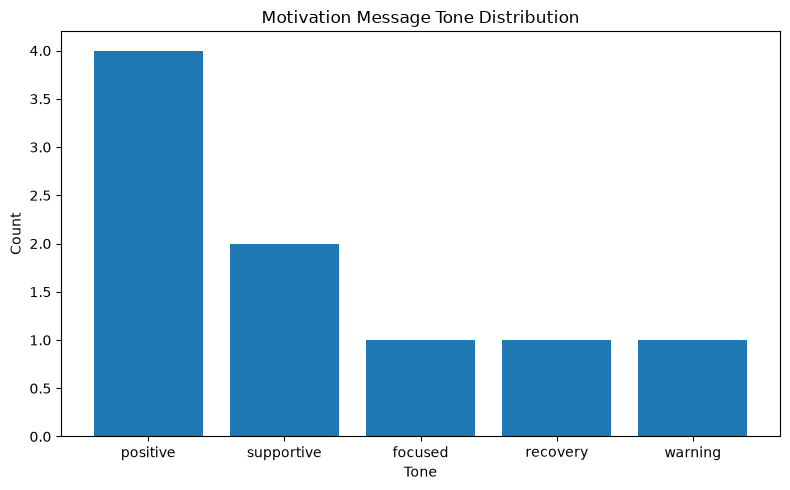

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\motivation_engine_tone_distribution.png


In [4]:
tone_counts = results_df["tone"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(tone_counts.index, tone_counts.values)
plt.title("Motivation Message Tone Distribution")
plt.xlabel("Tone")
plt.ylabel("Count")
plt.tight_layout()

output_path = FIGURES_DIR / "motivation_engine_tone_distribution.png"
plt.savefig(output_path, dpi=150)
plt.show()

print("Saved:", output_path)

## Chart confidence values

This chart shows confidence for each generated message.

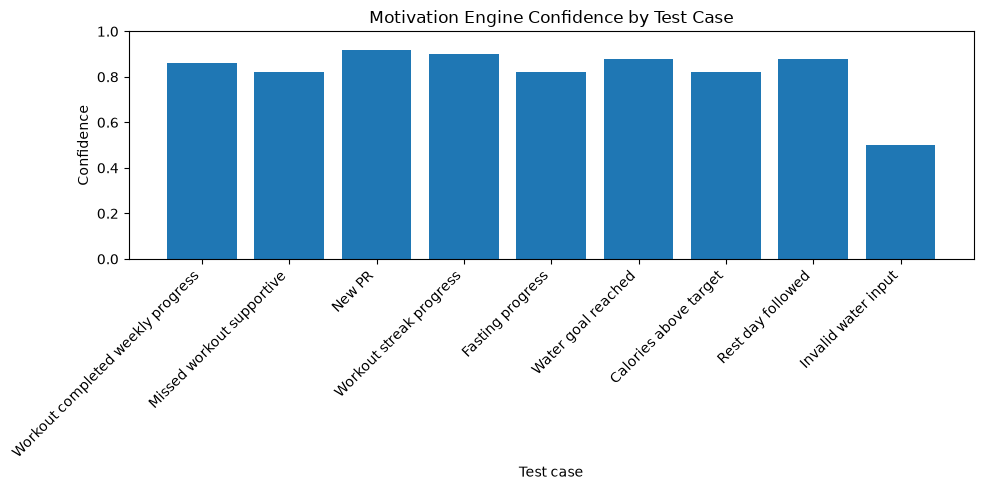

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\figures\motivation_engine_confidence.png


In [5]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["test_case"], results_df["confidence"])
plt.title("Motivation Engine Confidence by Test Case")
plt.xlabel("Test case")
plt.ylabel("Confidence")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

output_path = FIGURES_DIR / "motivation_engine_confidence.png"
plt.savefig(output_path, dpi=150)
plt.show()

print("Saved:", output_path)

## Save motivation engine test results

This saves the generated messages for review.

In [6]:
output_path = REPORTS_DIR / "motivation_engine_test_results.csv"
results_df.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: C:\Users\AI WORKPLACE\Documents\Project\AuraFitness\ai\reports\motivation_engine_test_results.csv


## Behavior validation

This validates important message behavior:

- PR messages should include PR reason code
- Invalid values should return warning tone

In [7]:
pr_row = results_df[results_df["test_case"] == "New PR"].iloc[0]

if pr_row["title"] != "New personal record":
    raise ValueError("Expected New personal record title.")

if "pr_value_available" not in pr_row["reason_codes"]:
    raise ValueError("Expected pr_value_available reason code.")

invalid_row = results_df[results_df["test_case"] == "Invalid water input"].iloc[0]

if invalid_row["tone"] != "warning":
    raise ValueError("Invalid input should return warning tone.")

if "water_liters_negative" not in invalid_row["reason_codes"]:
    raise ValueError("Expected water_liters_negative reason code.")

print("Motivation engine behavior validation passed.")

Motivation engine behavior validation passed.
